# Part A: CVAE vs. GAN Comparison

This notebook loads the final PyTorch CVAE and GAN checkpoints produced by their improvement notebooks and compares class fidelity, distributional similarity, training behaviour, visual quality, and within-class diversity to determine which architecture better suits CIFAR-10 generation.

## 1. Imports and Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import json

# Set random seed for reproducibility.
torch.manual_seed(42)
np.random.seed(42)

In [2]:
import seaborn as sns

# Shared design system for the Part A notebooks: one categorical color per CIFAR-10 class.
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

In [3]:
# Define the minimal decoder and generator classes required to load the saved PyTorch weights.
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')

import os
from datasets import Dataset as HFDataset, load_dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import normalized_mutual_info_score
from torchmetrics.image.fid import FrechetInceptionDistance

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.manual_seed_all(42)
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
num_classes = len(class_names)
noise_dim = 128
cpu_cores = min(16, os.cpu_count()-2 or 1)

def load_checkpoint_state_dict(path):
    return torch.load(Path(path), map_location="cpu", weights_only=True)

class Decoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + num_classes, 64 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        x = torch.cat([z, y], dim=1)
        x = self.fc(x).view(-1, 64, 8, 8)
        return self.deconv(x)

class DeepDecoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + num_classes, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        x = torch.cat([z, y], dim=1)
        x = self.fc(x).view(-1, 128, 4, 4)
        return self.deconv(x)

class generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        #activations
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()



    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)
        
        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.tanh(self.convT3(x))
        return x

class Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        return self.fc(self.conv(x).flatten(start_dim=1))

class BaselineClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(512, 10)

    def forward(self, x):
        return self.fc_out(self.relu(self.fc1(self.conv(x).flatten(start_dim=1))))

print("device:", device)

device: cuda


## 2. Load Final Models and Results

This notebook performs no training. It loads `vae_final_best.pt` and `best_gan.pt`, reconstructs the required decoder and generator definitions, and evaluates fresh fixed-seed samples; the saved source-notebook loss figures are reused for the stability comparison. The CVAE checkpoint resolves to a baseline-depth decoder with a `128`-dimensional latent space and the selected soft-augmentation setting. The GAN uses `128`-dimensional noise and its selected soft-augmentation setting.

In [4]:
# Load the final CVAE's native PyTorch weights and supporting results.
vae_checkpoint_path = Path("vae_final_best.pt")
if not vae_checkpoint_path.exists():
    raise FileNotFoundError(
        "No final CVAE checkpoint was found. Run vae_improvement.ipynb through its final-model save cell first."
    )

vae_state_dict = load_checkpoint_state_dict(vae_checkpoint_path)
vae_decoder_state = {
    name.removeprefix("decoder."): tensor
    for name, tensor in vae_state_dict.items()
    if name.startswith("decoder.")
}
if not vae_decoder_state:
    raise ValueError(f"{vae_checkpoint_path} does not contain CVAE decoder weights")

vae_latent_dim = vae_decoder_state["fc.weight"].shape[1] - num_classes
vae_uses_deep_architecture = "deconv.4.weight" in vae_decoder_state
vae_decoder_class = DeepDecoder if vae_uses_deep_architecture else Decoder
vae_decoder = vae_decoder_class(num_classes, vae_latent_dim).to(device)
vae_decoder.load_state_dict(vae_decoder_state)
vae_decoder.eval()

vae_results_path = Path("../../results/part_a/vae_improvement_results.json")
if vae_results_path.exists():
    with vae_results_path.open(encoding="utf-8") as file:
        vae_results = json.load(file)
else:
    vae_results = {}

with Path("../../results/part_a/vae_baseline_results.json").open(encoding="utf-8") as file:
    vae_baseline_results = json.load(file)

def load_cifar10_train_split():
    cache_root = Path.home() / '.cache' / 'huggingface' / 'datasets' / 'uoft-cs___cifar10'
    cached_files = list(cache_root.rglob('cifar10-train.arrow')) if cache_root.exists() else []
    if cached_files:
        cache_file = max(cached_files, key=lambda path: path.stat().st_mtime)
        print('Loading cached CIFAR-10 train split')
        return HFDataset.from_file(str(cache_file))
    return load_dataset('uoft-cs/cifar10', split='train')

class CIFARValidationDataset(TorchDataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return {'img': self.images[index], 'label': self.labels[index]}

train_values = load_cifar10_train_split().with_format('torch')[:]
train_images = train_values['img'].float() / 127.5 - 1
train_labels = F.one_hot(train_values['label'].long(), num_classes=num_classes).float()
validation_indices = torch.randperm(
    len(train_images), generator=torch.Generator().manual_seed(42)
)[:5000]
val_data = CIFARValidationDataset(
    train_images[validation_indices], train_labels[validation_indices]
)
val_loader = DataLoader(
    val_data,
    batch_size=128,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)

classifier_checkpoint_path = Path("vae_classifier.pt")
if not classifier_checkpoint_path.exists():
    raise FileNotFoundError(
        "No frozen VAE classifier checkpoint was found. Run vae_baseline.ipynb through its classifier save cell first."
    )

classifier_state_dict = load_checkpoint_state_dict(classifier_checkpoint_path)
classifier_class = BaselineClassifier if "fc_out.weight" in classifier_state_dict else Classifier
classifier = classifier_class(num_classes).to(device)
classifier.load_state_dict(classifier_state_dict)
classifier.eval()
for parameter in classifier.parameters():
    parameter.requires_grad_(False)

vae_config = {
    "checkpoint": str(vae_checkpoint_path),
    "latent_dim": vae_latent_dim,
    "architecture": "deep" if vae_uses_deep_architecture else "baseline",
}
print("Loaded CVAE:", vae_config)
print("Loaded frozen classifier from", classifier_checkpoint_path)

Loading cached CIFAR-10 train split


Loaded CVAE: {'checkpoint': 'vae_final_best.pt', 'latent_dim': 128, 'architecture': 'baseline'}
Loaded frozen classifier from vae_classifier.pt


In [5]:
# Load the final GAN's native PyTorch weights and supporting results.
gan_checkpoint_path = Path("best_gan.pt")
if not gan_checkpoint_path.exists():
    raise FileNotFoundError(
        "No final GAN checkpoint was found. Run gan_improvement.ipynb through its final-model save cell first."
    )

gan_model = generator(noise_dim).to(device)
gan_model.load_state_dict(load_checkpoint_state_dict(gan_checkpoint_path))
gan_model.eval()

with Path("../../results/part_a/gan_experiment_results.json").open(encoding="utf-8") as file:
    gan_results = json.load(file)
with Path("../../results/part_a/gan_baseline_results.json").open(encoding="utf-8") as file:
    gan_baseline_results = json.load(file)

gan_config = {
    "checkpoint": str(gan_checkpoint_path),
    "noise_dim": noise_dim,
    "selected_setting": "soft_augmentation",
}
print("Loaded GAN:", gan_config)

Loaded GAN: {'checkpoint': 'best_gan.pt', 'noise_dim': 128, 'selected_setting': 'soft_augmentation'}


## 3. Quantitative Comparison

### 3.1 Overall Class Fidelity, Per-Class Agreement, and FID

Both models are evaluated with the same frozen CIFAR-10 classifier. NMI measures the dependence between the requested and predicted labels, while per-class classifier agreement checks whether each generated image is assigned its requested class. FID is recomputed for both models from `1,000` generated images against the same seeded Hugging Face CIFAR-10 validation sample using the same TorchMetrics Inception extractor, so the two FID values are directly comparable (lower is better). The classifier-based measures remain proxies for class fidelity because they also depend on the frozen classifier's own errors.

In [6]:
# Build a table of overall and per-class quality scores plus FID for the CVAE final model vs. the GAN final model.
from IPython.display import display

images_per_class = 100

torch.manual_seed(42)
vae_generated_images = []
vae_generated_labels = []
with torch.no_grad():
    for class_idx in range(num_classes):
        z = torch.randn(images_per_class, vae_latent_dim, device=device)
        y = torch.zeros(images_per_class, num_classes, device=device)
        y[:, class_idx] = 1
        vae_generated_images.append(vae_decoder(z, y).cpu())
        vae_generated_labels.append(torch.full((images_per_class,), class_idx))
vae_generated_images = torch.cat(vae_generated_images)
vae_generated_labels = torch.cat(vae_generated_labels)

torch.manual_seed(42)
gan_generated_images = []
gan_generated_labels = []
with torch.no_grad():
    for class_idx in range(num_classes):
        noise = torch.randn(images_per_class, noise_dim, device=device)
        one_hot_labels = torch.zeros(images_per_class, num_classes, device=device)
        one_hot_labels[:, class_idx] = 1
        gan_generated_images.append(gan_model(noise, one_hot_labels).cpu())
        gan_generated_labels.append(torch.full((images_per_class,), class_idx))
gan_generated_images = torch.cat(gan_generated_images)
gan_generated_labels = torch.cat(gan_generated_labels)
gan_generated_images_01 = ((gan_generated_images + 1) / 2).clamp(0, 1)

def classify_generated_images(images, batch_size=128):
    predictions = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = images[start:start + batch_size].to(device)
            predictions.append(classifier(batch).argmax(dim=1).cpu())
    return torch.cat(predictions)

vae_predicted_labels = classify_generated_images(vae_generated_images)
gan_predicted_labels = classify_generated_images(gan_generated_images_01)

vae_nmi = normalized_mutual_info_score(
    vae_generated_labels.numpy(), vae_predicted_labels.numpy()
)
gan_nmi = normalized_mutual_info_score(
    gan_generated_labels.numpy(), gan_predicted_labels.numpy()
)

vae_per_class_scores = [
    (vae_predicted_labels[vae_generated_labels == class_idx] == class_idx).float().mean().item()
    for class_idx in range(num_classes)
]
gan_per_class_scores = [
    (gan_predicted_labels[gan_generated_labels == class_idx] == class_idx).float().mean().item()
    for class_idx in range(num_classes)
]

def compute_common_fid(real_images, fake_images, batch_size=128):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    with torch.no_grad():
        for start in range(0, len(real_images), batch_size):
            fid.update(real_images[start:start + batch_size].to(device), real=True)
        for start in range(0, len(fake_images), batch_size):
            fid.update(fake_images[start:start + batch_size].to(device), real=False)
    score = fid.compute().item()
    del fid
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return score

fid_n_samples = images_per_class * num_classes
real_fid_batches = []
real_samples_seen = 0
for sample in val_loader:
    remaining = fid_n_samples - real_samples_seen
    if remaining == 0:
        break
    real_images = sample["img"][:remaining]
    real_images = ((real_images + 1) / 2).clamp(0, 1)
    real_fid_batches.append(real_images)
    real_samples_seen += len(real_images)
real_fid_images = torch.cat(real_fid_batches)
vae_fid = compute_common_fid(real_fid_images, vae_generated_images)
gan_fid = compute_common_fid(real_fid_images, gan_generated_images_01)

per_class_quality_scores = pd.DataFrame(
    {"CVAE": vae_per_class_scores, "GAN": gan_per_class_scores},
    index=class_names,
)
comparison_table = pd.concat(
    [
        pd.DataFrame(
            {"CVAE": [vae_nmi], "GAN": [gan_nmi]},
            index=["overall_nmi"],
        ),
        per_class_quality_scores.rename(
            index=lambda class_name: f"{class_name}_classifier_agreement"
        ),
        pd.DataFrame(
            {"CVAE": [vae_fid], "GAN": [gan_fid]},
            index=["fid_score"],
        ),
    ]
)

vae_results["comparison"] = {
    "nmi_score": vae_nmi,
    "per_class_classifier_agreement": dict(zip(class_names, vae_per_class_scores)),
    "fid_score": vae_fid,
}
gan_results["final_model_comparison"] = {
    "nmi_score": gan_nmi,
    "per_class_classifier_agreement": dict(zip(class_names, gan_per_class_scores)),
    "fid_score": gan_fid,
}
display(comparison_table.round(4))

,CVAE,GAN
overall_nmi,0.1177,0.1982
airplane_classifier_agreement,0.2600,0.4800
automobile_classifier_agreement,0.0700,0.5700
bird_classifier_agreement,0.4200,0.1300
cat_classifier_agreement,0.4400,0.3000
deer_classifier_agreement,0.3700,0.4100
dog_classifier_agreement,0.0900,0.2700
frog_classifier_agreement,0.0100,0.2400
horse_classifier_agreement,0.0700,0.1900
ship_classifier_agreement,0.6100,0.3700


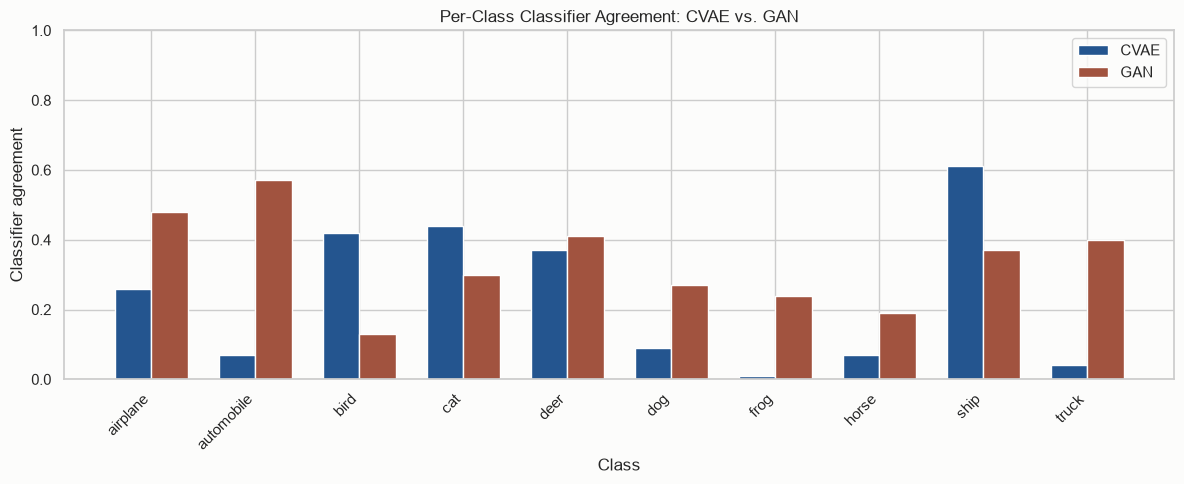

In [7]:
# Grouped bar chart: per-class quality score, CVAE vs. GAN side by side.
x = np.arange(num_classes)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, per_class_quality_scores["CVAE"], width, label="CVAE", color=PALETTE[3])
ax.bar(x + width / 2, per_class_quality_scores["GAN"], width, label="GAN", color=PALETTE[0])
ax.set_title("Per-Class Classifier Agreement: CVAE vs. GAN")
ax.set_xlabel("Class")
ax.set_ylabel("Classifier agreement")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion

The GAN achieved higher overall NMI (`0.1982` versus `0.1177`) and lower FID (`122.694` versus `179.661`), a `31.71%` FID reduction relative to the CVAE. It led classifier agreement in seven of ten classes, with the largest margins for automobile (`0.57` versus `0.07`), truck (`0.40` versus `0.04`), and frog (`0.24` versus `0.01`). The CVAE performed better for bird (`0.42` versus `0.13`), ship (`0.61` versus `0.37`), and cat (`0.44` versus `0.30`), but these three class-specific advantages did not offset the GAN's stronger overall class separation and distributional similarity.

### 3.2 Training Stability

The two architectures have different stability signals, so each is assessed in its natural terms rather than through one shared loss value. The CVAE plot tracks its reconstruction-plus-KL objective for training and validation, whereas the GAN plot tracks generator loss and the discriminator's real/fake components as its two networks compete. Their absolute loss magnitudes are therefore not directly comparable; the relevant evidence is the shape and variability of each set of curves.

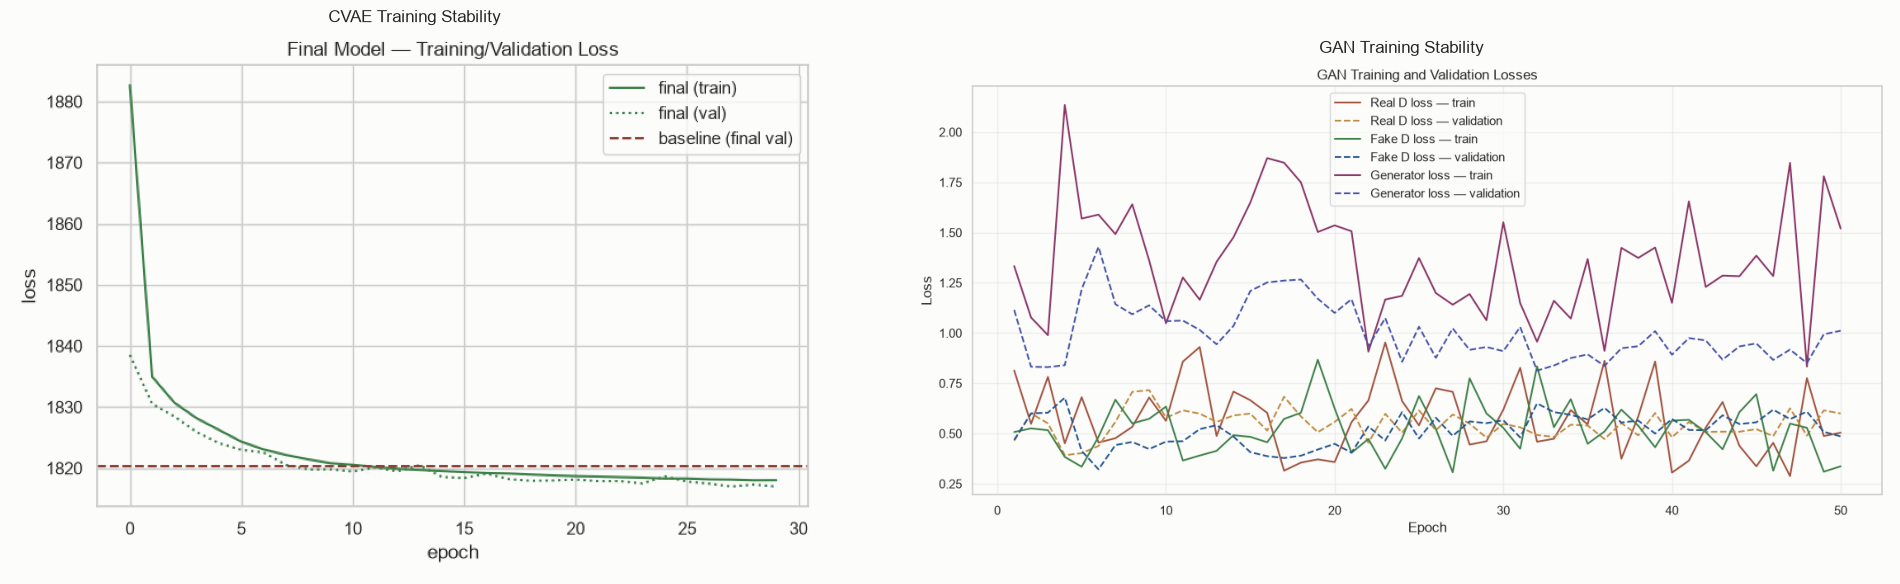

In [8]:
# Plot the CVAE's validation loss curve and the GAN's G/D loss curves side by side (two subplots), each in its own natural terms.
import base64
from io import BytesIO
from PIL import Image

def load_saved_notebook_figure(notebook_path, source_prefix):
    with Path(notebook_path).open(encoding="utf-8") as file:
        notebook = json.load(file)

    source_cell = next(
        (
            cell
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
            and "".join(cell["source"]).startswith(source_prefix)
        ),
        None,
    )
    if source_cell is None:
        raise RuntimeError(f"Could not find the requested plot cell in {notebook_path}")

    for output in reversed(source_cell.get("outputs", [])):
        image_data = output.get("data", {}).get("image/png")
        if image_data:
            encoded = "".join(image_data) if isinstance(image_data, list) else image_data
            return np.asarray(Image.open(BytesIO(base64.b64decode(encoded))).convert("RGB"))

    raise RuntimeError(
        f"The requested plot is not saved in {notebook_path}. Run that source plot cell and save the notebook first."
    )

vae_loss_figure = load_saved_notebook_figure(
    "vae_improvement.ipynb",
    "# Plot the final model's training/validation loss curves against the baseline's",
)
gan_loss_figure = load_saved_notebook_figure(
    "gan_improvement.ipynb",
    "# Plot the final model's generator/discriminator loss curves.",
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes[0].imshow(vae_loss_figure)
axes[0].set_title("CVAE Training Stability")
axes[0].axis("off")
axes[1].imshow(gan_loss_figure)
axes[1].set_title("GAN Training Stability")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Conclusion

The CVAE training and validation losses declined steeply during the early epochs and then approached a stable plateau, with final validation loss `1,816.97` and only small late fluctuations. In contrast, the GAN curves remained oscillatory across all `50` epochs: generator loss showed repeated spikes while the real and fake discriminator components continued moving against it, ending at approximately `1.012`, `0.600`, and `0.486` on validation. The CVAE therefore exhibited the smoother optimization path, while the GAN was less stable to train despite its stronger generated-image metrics.

## 4. Qualitative Comparison

### 4.1 Side-by-Side Sample Grid

Five shared classes are generated from both final models with three independently sampled images per class and displayed in matched rows. The fixed seed and identical label order keep class coverage consistent, while converting the GAN's `[-1, 1]` outputs to the CVAE's `[0, 1]` display range prevents a scale difference from affecting the visual comparison.

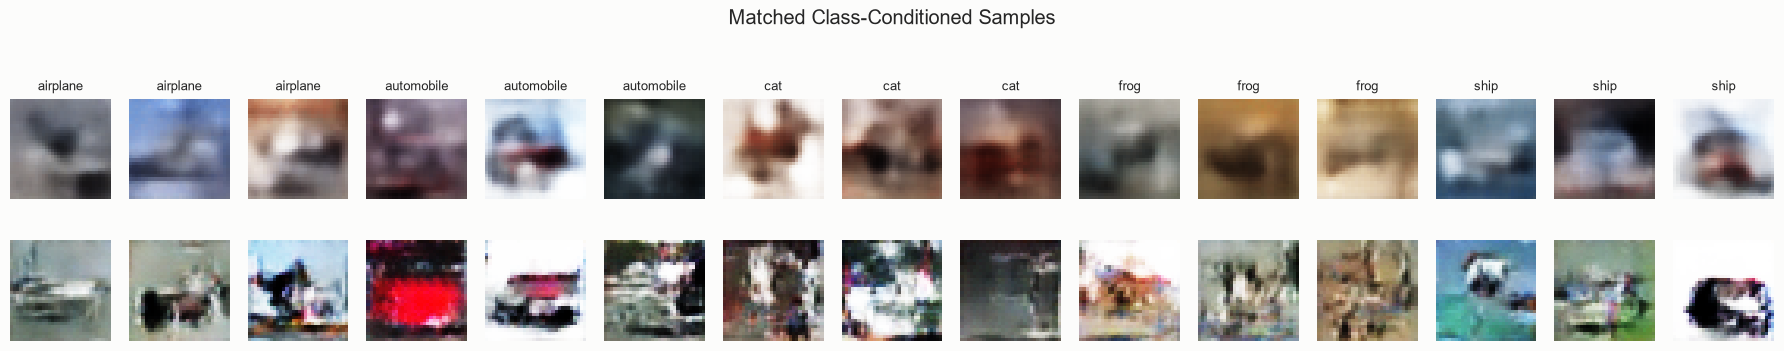

In [9]:
# For a handful of classes, generate one row of CVAE images and one row of GAN images, displayed in the same grid for direct visual comparison.
selected_class_indices = [0, 1, 3, 6, 8]
samples_per_class = 3
grid_labels = torch.tensor(selected_class_indices).repeat_interleave(samples_per_class)
grid_one_hot = F.one_hot(grid_labels, num_classes=num_classes).float().to(device)

torch.manual_seed(42)
with torch.no_grad():
    vae_grid_images = vae_decoder(
        torch.randn(len(grid_labels), vae_latent_dim, device=device),
        grid_one_hot,
    ).cpu()

torch.manual_seed(42)
with torch.no_grad():
    gan_grid_images = gan_model(
        torch.randn(len(grid_labels), noise_dim, device=device),
        grid_one_hot,
    ).cpu()
gan_grid_images = ((gan_grid_images + 1) / 2).clamp(0, 1)

fig, axes = plt.subplots(2, len(grid_labels), figsize=(18, 4))
for col, class_idx in enumerate(grid_labels.tolist()):
    axes[0, col].imshow(vae_grid_images[col].permute(1, 2, 0).numpy())
    axes[1, col].imshow(gan_grid_images[col].permute(1, 2, 0).numpy())
    axes[0, col].set_title(class_names[class_idx], fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("CVAE", fontsize=11)
axes[1, 0].set_ylabel("GAN", fontsize=11)
fig.suptitle("Matched Class-Conditioned Samples")
plt.tight_layout()
plt.show()

### Conclusion

The GAN row is visibly sharper and higher-contrast, with the clearest recognizable cues appearing in several automobile and ship samples. The CVAE row is smoother but substantially blurrier, so many class identities remain ambiguous even when broad color and silhouette cues are present. The GAN samples also vary more in structure and background, although several contain strong pixelation, oversaturated regions, or distorted objects. The grid therefore supports the GAN's quantitative advantage while showing that some of its added sharpness and variation comes with visible artifacts.

### 4.2 Diversity Check

Within-class diversity is measured with the exact pixel-level statistic used in `gan_baseline.ipynb`: for `128` independently generated images per class, the standard deviation at every pixel and channel is averaged into one score. GAN outputs are first mapped to `[0, 1]` so both models are measured on the same scale. A higher value indicates more pixel variation, but it does not by itself prove semantic diversity because noise and artifacts can also raise the score.

,CVAE,GAN
airplane,0.2040,0.2462
automobile,0.2130,0.2409
bird,0.1988,0.2126
cat,0.2101,0.2433
deer,0.1961,0.1971
dog,0.2155,0.2271
frog,0.1951,0.2020
horse,0.2183,0.2310
ship,0.2030,0.2191
truck,0.2161,0.2417


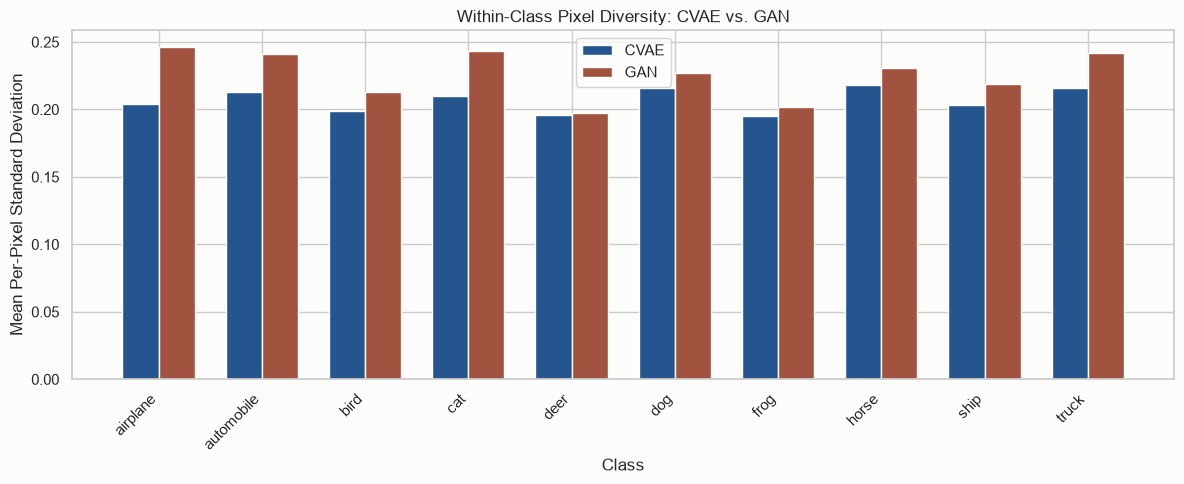

In [10]:
# Compute the same pixel-diversity metric (from gan_baseline.ipynb Section 8.2) for a batch of same-class images from both models, compare the numbers.
n_generated_samples = 128
vae_diversity_scores = {}
gan_diversity_scores = {}

torch.manual_seed(42)
with torch.no_grad():
    for class_idx, class_name in enumerate(class_names):
        vae_labels = torch.zeros(n_generated_samples, num_classes, device=device)
        vae_labels[:, class_idx] = 1
        vae_images = vae_decoder(
            torch.randn(n_generated_samples, vae_latent_dim, device=device),
            vae_labels,
        )
        vae_diversity_scores[class_name] = vae_images.std(dim=0).mean().item()

torch.manual_seed(42)
with torch.no_grad():
    for class_idx, class_name in enumerate(class_names):
        gan_labels = torch.zeros(n_generated_samples, num_classes, device=device)
        gan_labels[:, class_idx] = 1
        gan_images = gan_model(
            torch.randn(n_generated_samples, noise_dim, device=device),
            gan_labels,
        )
        gan_images = ((gan_images + 1) / 2).clamp(0, 1)
        gan_diversity_scores[class_name] = gan_images.std(dim=0).mean().item()

diversity_table = pd.DataFrame(
    {"CVAE": vae_diversity_scores, "GAN": gan_diversity_scores}
)
display(diversity_table.round(4))

x = np.arange(num_classes)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, diversity_table["CVAE"], width, label="CVAE", color=PALETTE[3])
ax.bar(x + width / 2, diversity_table["GAN"], width, label="GAN", color=PALETTE[0])
ax.set_title("Within-Class Pixel Diversity: CVAE vs. GAN")
ax.set_xlabel("Class")
ax.set_ylabel("Mean Per-Pixel Standard Deviation")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Discussion: Which Architecture Wins, and Why

The GAN is the stronger architecture in this comparison: its NMI was `68.4%` higher (`0.1982` versus `0.1177`), it reduced FID from `179.661` to `122.694`, and it led classifier agreement in seven classes, while the CVAE retained advantages for bird, cat, and ship. Mean pixel diversity was also higher for the GAN (`0.2261` versus `0.2070`), and the GAN exceeded the CVAE in every class on this statistic; however, the sample grid shows that some additional variation comes from visible artifacts rather than meaningful object diversity. The results are consistent with the CVAE reconstruction objective averaging across plausible outputs, producing smoother optimization and blurrier samples, while adversarial training rewards sharper detail but yields the oscillatory GAN loss curves. The evidence therefore favours the GAN for distributional similarity and class separation, with training stability and artifacts as its main trade-offs.

## 6. Conclusion

The final GAN performed better on the current CIFAR-10 generation comparison: its NMI was `68.4%` higher, its FID was `31.71%` lower, and its samples were sharper with higher measured pixel diversity. These gains came with more oscillatory training and visible pixelation or distortion in some samples. The CVAE was smoother to optimize but produced blurrier outputs with weaker overall class separation. The evaluated native PyTorch checkpoints are `vae_final_best.pt` and `best_gan.pt`.

## 7. Export Final GAN Images

Generate 100 images for each CIFAR-10 class and save the resulting 1,000 PNG files under `final-images/<class>/`.

In [11]:
from torchvision.utils import save_image
from pathlib import Path

final_images_dir = Path("final-images")
images_per_class = 100

# Use a fixed seed so rerunning this export produces the same images.
torch.manual_seed(42)
gan_model.eval()

with torch.inference_mode():
    for class_idx, class_name in enumerate(class_names):
        class_dir = final_images_dir / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.zeros(images_per_class, num_classes, device=device)
        labels[:, class_idx] = 1
        noise = torch.randn(images_per_class, noise_dim, device=device)
        images = gan_model(noise, labels)
        images = ((images + 1) / 2).clamp(0, 1).cpu()

        for image_idx, image in enumerate(images):
            save_image(image, class_dir / f"{class_name}_{image_idx:03d}.png")

image_counts = {
    class_name: len(list((final_images_dir / class_name).glob("*.png")))
    for class_name in class_names
}
assert all(count == images_per_class for count in image_counts.values()), image_counts
print(f"Saved {sum(image_counts.values())} images to {final_images_dir}")
print(image_counts)

Saved 1000 images to final-images
{'airplane': 100, 'automobile': 100, 'bird': 100, 'cat': 100, 'deer': 100, 'dog': 100, 'frog': 100, 'horse': 100, 'ship': 100, 'truck': 100}
